In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.metrics import accuracy_score,confusion_matrix

In [2]:
data=pd.read_csv('Air_quality_dataSet.csv',encoding='unicode_escape')

In [3]:
# Keep only rows where location is 'Delhi'
data = data[data["location"] == "Delhi"]

# Reset index after filtering
data.reset_index(drop=True, inplace=True)
# data.dropna(inplace=True)
# data.shape

# Check the first few rows
data.head()


,stn_code,sampling_date,state,location,agency,type,so2,no2,rspm,spm,location_monitoring_station,pm2_5,date
0,60,9/1/1987,Delhi,Delhi,Central Pollution Control Board,Residential,8.6,16.2,NaN,323.0,NaN,NaN,1987-01-09
1,59,9/2/1987,Delhi,Delhi,Central Pollution Control Board,Residential,6.5,9.3,NaN,488.0,NaN,NaN,1987-02-09
2,58,9/3/1987,Delhi,Delhi,Central Pollution Control Board,Industrial,25.8,10.4,NaN,487.0,NaN,NaN,1987-03-09
3,57,9/3/1987,Delhi,Delhi,Central Pollution Control Board,Industrial,0.5,2.8,NaN,528.0,NaN,NaN,1987-03-09
4,56,9/2/1987,Delhi,Delhi,Central Pollution Control Board,Industrial,2.5,12.8,NaN,506.0,NaN,NaN,1987-02-09


In [4]:
data['type'].value_counts()

type
Residential, Rural and other Areas    3063
Residential and others                2204
Industrial Area                       2159
Industrial Areas                      1101
Industrial                              16
Residential                              8
Name: count, dtype: int64

[]

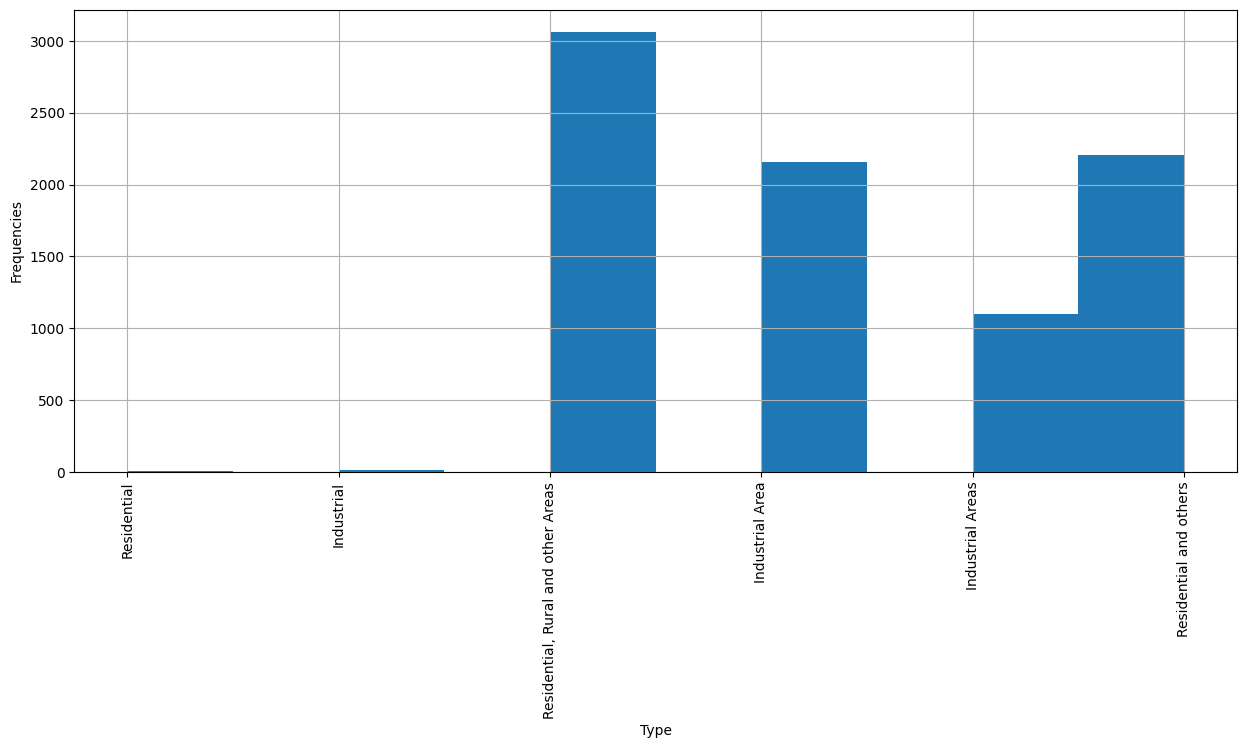

In [5]:
plt.figure(figsize=(15, 6))
plt.xticks(rotation=90)
data.type.hist()
plt.xlabel('Type')
plt.ylabel('Frequencies')
plt.plot()
# The visualization shows us the count of Types present in the dataset.

In [6]:
nullvalues = data.isnull().sum().sort_values(ascending=False)
# Checking all null values
nullvalues

pm2_5                          8180
agency                         3956
stn_code                       3305
spm                            3092
location_monitoring_station    2022
rspm                           1884
so2                             741
no2                             544
sampling_date                     0
location                          0
state                             0
type                              0
date                              0
dtype: int64

In [7]:
null_values_percentage = (data.isnull().sum()/data.isnull().count()*100).sort_values(ascending=False)
missing_data_with_percentage = pd.concat([nullvalues, null_values_percentage], axis=1, keys=['Total', 'Percent'])
missing_data_with_percentage


,Total,Percent
pm2_5,8180,95.661326
agency,3956,46.263595
stn_code,3305,38.650450
spm,3092,36.159514
location_monitoring_station,2022,23.646357
rspm,1884,22.032511
so2,741,8.665653
no2,544,6.361829
sampling_date,0,0.000000
location,0,0.000000


In [8]:
data.drop(['agency'],axis=1,inplace=True)
data.drop(['stn_code'],axis=1,inplace=True)
data.drop(['date'],axis=1,inplace=True)
data.drop(['sampling_date'],axis=1,inplace=True)
data.drop(['location_monitoring_station'],axis=1,inplace=True)
# Dropping unnecessary columns

In [9]:
data.isnull().sum()

state          0
location       0
type           0
so2          741
no2          544
rspm        1884
spm         3092
pm2_5       8180
dtype: int64

In [10]:
# data.fillna(0, inplace=True)
data


,state,location,type,so2,no2,rspm,spm,pm2_5
0,Delhi,Delhi,Residential,8.6,16.2,NaN,323.0,NaN
1,Delhi,Delhi,Residential,6.5,9.3,NaN,488.0,NaN
2,Delhi,Delhi,Industrial,25.8,10.4,NaN,487.0,NaN
3,Delhi,Delhi,Industrial,0.5,2.8,NaN,528.0,NaN
4,Delhi,Delhi,Industrial,2.5,12.8,NaN,506.0,NaN
...,...,...,...,...,...,...,...,...
8546,Delhi,Delhi,"Residential, Rural and other Areas",4.0,56.0,246.0,NaN,NaN
8547,Delhi,Delhi,"Residential, Rural and other Areas",4.0,54.0,269.0,NaN,NaN
8548,Delhi,Delhi,"Residential, Rural and other Areas",4.0,53.0,205.0,NaN,NaN
8549,Delhi,Delhi,"Residential, Rural and other Areas",5.0,43.0,142.0,NaN,NaN


In [11]:
data['location']=data['location'].fillna(data['location'].mode()[0])
data['type']=data['type'].fillna(data['type'].mode()[0])
# Null value Imputation for categorical data

In [12]:
data.fillna(0, inplace=True)


In [13]:
print(data.columns)


Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'pm2_5'], dtype='object')


In [14]:
data.isnull().sum()

state       0
location    0
type        0
so2         0
no2         0
rspm        0
spm         0
pm2_5       0
dtype: int64

In [15]:
data

,state,location,type,so2,no2,rspm,spm,pm2_5
0,Delhi,Delhi,Residential,8.6,16.2,0.0,323.0,0.0
1,Delhi,Delhi,Residential,6.5,9.3,0.0,488.0,0.0
2,Delhi,Delhi,Industrial,25.8,10.4,0.0,487.0,0.0
3,Delhi,Delhi,Industrial,0.5,2.8,0.0,528.0,0.0
4,Delhi,Delhi,Industrial,2.5,12.8,0.0,506.0,0.0
...,...,...,...,...,...,...,...,...
8546,Delhi,Delhi,"Residential, Rural and other Areas",4.0,56.0,246.0,0.0,0.0
8547,Delhi,Delhi,"Residential, Rural and other Areas",4.0,54.0,269.0,0.0,0.0
8548,Delhi,Delhi,"Residential, Rural and other Areas",4.0,53.0,205.0,0.0,0.0
8549,Delhi,Delhi,"Residential, Rural and other Areas",5.0,43.0,142.0,0.0,0.0


In [16]:
print(data.columns)


Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'pm2_5'], dtype='object')


In [17]:
def cal_SOi(so2):
    si=0
    if (so2<=40):
     si= so2*(50/40)
    elif (so2>40 and so2<=80):
     si= 50+(so2-40)*(50/40)
    elif (so2>80 and so2<=380):
     si= 100+(so2-80)*(100/300)
    elif (so2>380 and so2<=800):
     si= 200+(so2-380)*(100/420)
    elif (so2>800 and so2<=1600):
     si= 300+(so2-800)*(100/800)
    elif (so2>1600):
     si= 400+(so2-1600)*(100/800)
    return si
data['SOi']=data['so2'].apply(cal_SOi)
data_1= data[['so2','SOi']]
data_1.head()

,so2,SOi
0,8.6,10.750
1,6.5,8.125
2,25.8,32.250
3,0.5,0.625
4,2.5,3.125


In [18]:
print(data.columns)

Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'pm2_5',
       'SOi'],
      dtype='object')


In [19]:
def cal_Noi(no2):
    ni=0
    if(no2<=40):
     ni= no2*50/40
    elif(no2>40 and no2<=80):
     ni= 50+(no2-40)*(50/40)
    elif(no2>80 and no2<=180):
     ni= 100+(no2-80)*(100/100)
    elif(no2>180 and no2<=280):
     ni= 200+(no2-180)*(100/100)
    elif(no2>280 and no2<=400):
     ni= 300+(no2-280)*(100/120)
    else:
     ni= 400+(no2-400)*(100/120)
    return ni
data['Noi']=data['no2'].apply(cal_Noi)
data_1= data[['no2','Noi']]
data_1.head()
# calculating the individual pollutant index for no2(nitrogen dioxide)

,no2,Noi
0,16.2,20.250
1,9.3,11.625
2,10.4,13.000
3,2.8,3.500
4,12.8,16.000


In [20]:
# Function to calculate rspm individual pollutant index(rpi)¶
def cal_RSPMI(rspm):
    rpi=0
    if(rpi<=30):
     rpi=rpi*50/30
    elif(rpi>30 and rpi<=60):
     rpi=50+(rpi-30)*50/30
    elif(rpi>60 and rpi<=90):
     rpi=100+(rpi-60)*100/30
    elif(rpi>90 and rpi<=120):
     rpi=200+(rpi-90)*100/30
    elif(rpi>120 and rpi<=250):
     rpi=300+(rpi-120)*(100/130)
    else:
     rpi=400+(rpi-250)*(100/130)
    return rpi
data['Rpi']=data['rspm'].apply(cal_RSPMI)
data_1= data[['rspm','Rpi']]
data_1.head()


,rspm,Rpi
0,0.0,0.0
1,0.0,0.0
2,0.0,0.0
3,0.0,0.0
4,0.0,0.0


In [21]:
# Function to calculate spm individual pollutant index(spi)
def cal_SPMi(spm):
    spi=0
    if(spm<=50):
     spi=spm*50/50
    elif(spm>50 and spm<=100):
     spi=50+(spm-50)*(50/50)
    elif(spm>100 and spm<=250):
     spi= 100+(spm-100)*(100/150)
    elif(spm>250 and spm<=350):
     spi=200+(spm-250)*(100/100)
    elif(spm>350 and spm<=430):
     spi=300+(spm-350)*(100/80)
    else:
     spi=400+(spm-430)*(100/430)
    return spi
   
data['SPMi']=data['spm'].apply(cal_SPMi)
data_1= data[['spm','SPMi']]
data_1.head()
# calculating the individual pollutant index for spm(suspended particulate matter)

,spm,SPMi
0,323.0,273.000000
1,488.0,413.488372
2,487.0,413.255814
3,528.0,422.790698
4,506.0,417.674419


In [22]:
# function to calculate the air quality index (AQI) of every data_1 value¶
def cal_aqi(si,ni,rspmi,spmi):
    aqi=0
    if(si>ni and si>rspmi and si>spmi):
     aqi=si
    if(ni>si and ni>rspmi and ni>spmi):
     aqi=ni
    if(rspmi>si and rspmi>ni and rspmi>spmi):
     aqi=rspmi
    if(spmi>si and spmi>ni and spmi>rspmi):
     aqi=spmi
    return aqi

data['AQI']=data.apply(lambda x:cal_aqi(x['SOi'],x['Noi'],x['Rpi'],x['SPMi']),axis=1)
data_1= data[['state','type','SOi','Noi','Rpi','SPMi','AQI']]
data_1.head()
# Caluclating the Air Quality Index.

,state,type,SOi,Noi,Rpi,SPMi,AQI
0,Delhi,Residential,10.750,20.250,0.0,273.000000,273.000000
1,Delhi,Residential,8.125,11.625,0.0,413.488372,413.488372
2,Delhi,Industrial,32.250,13.000,0.0,413.255814,413.255814
3,Delhi,Industrial,0.625,3.500,0.0,422.790698,422.790698
4,Delhi,Industrial,3.125,16.000,0.0,417.674419,417.674419


     AQI Category  Percentage
0       Hazardous   23.248743
1            Poor   21.564729
2        Moderate   19.529880
3       Unhealthy   16.185241
4  Very Unhealthy   11.016255
5            Good    8.455151


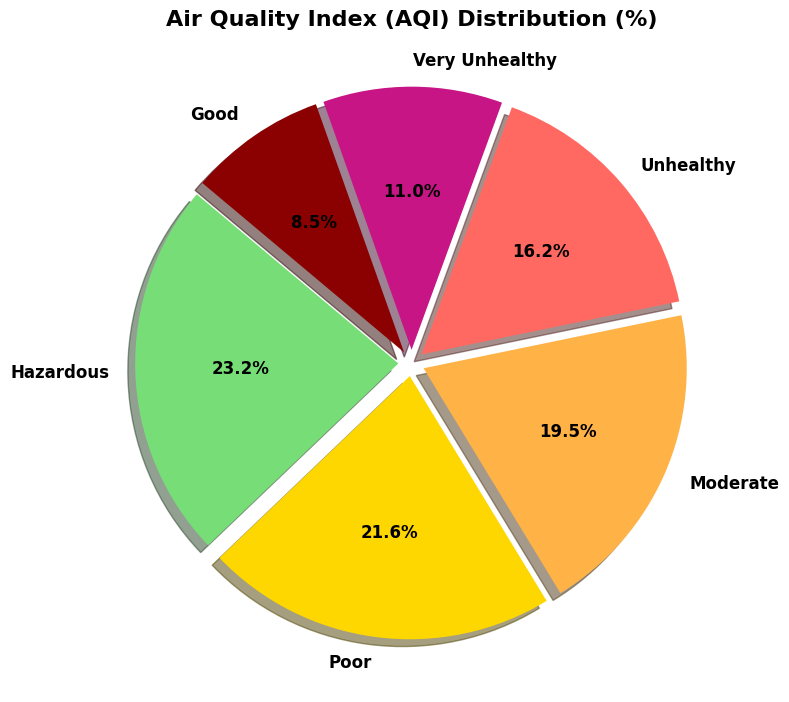

In [23]:
import matplotlib.pyplot as plt

# ---- Step 1: Classify AQI into categories ----
def AQI_Range(x):
    if x <= 50:
        return "Good"
    elif x <= 100:
        return "Moderate"
    elif x <= 200:
        return "Poor"
    elif x <= 300:
        return "Unhealthy"
    elif x <= 400:
        return "Very Unhealthy"
    else:
        return "Hazardous"

data['AQI_Range'] = data['AQI'].apply(AQI_Range)

# ---- Step 2: Calculate Percentage Distribution ----
aqi_percentage = data['AQI_Range'].value_counts(normalize=True) * 100

# Display as a table
aqi_percentage_table = aqi_percentage.reset_index()
aqi_percentage_table.columns = ['AQI Category', 'Percentage']
print(aqi_percentage_table)

# ---- Step 3: Pie Chart ----
plt.figure(figsize=(8, 8))
colors = ['#77DD77', '#FFD700', '#FFB347', '#FF6961', '#C71585', '#8B0000']  # AQI severity colors
explode = (0.05, 0.05, 0.05, 0.05, 0.05, 0.05)  # Slightly separate each slice

plt.pie(
    aqi_percentage,
    labels=aqi_percentage.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# ---- Step 4: Customize Plot ----
plt.title('Air Quality Index (AQI) Distribution (%)', fontsize=16, fontweight='bold')
plt.tight_layout()

# ---- Step 5: Show Chart ----
plt.show()


In [24]:
def AQI_Range(x):
    if x<=50:
        return "Good"
    elif x>50 and x<=100:
        return "Moderate"
    elif x>100 and x<=200:
        return "Poor"
    elif x>200 and x<=300:
        return "Unhealthy"
    elif x>300 and x<=400:
        return "Very unhealthy"
    elif x>400:
        return "Hazardous"

data['AQI_Range'] = data['AQI'] .apply(AQI_Range)
data.head()
# Using threshold values to classify a particular values as good, moderate, poor, unhealthy, very unhealthy and Hazardous

,state,location,type,so2,no2,rspm,spm,pm2_5,SOi,Noi,Rpi,SPMi,AQI,AQI_Range
0,Delhi,Delhi,Residential,8.6,16.2,0.0,323.0,0.0,10.750,20.250,0.0,273.000000,273.000000,Unhealthy
1,Delhi,Delhi,Residential,6.5,9.3,0.0,488.0,0.0,8.125,11.625,0.0,413.488372,413.488372,Hazardous
2,Delhi,Delhi,Industrial,25.8,10.4,0.0,487.0,0.0,32.250,13.000,0.0,413.255814,413.255814,Hazardous
3,Delhi,Delhi,Industrial,0.5,2.8,0.0,528.0,0.0,0.625,3.500,0.0,422.790698,422.790698,Hazardous
4,Delhi,Delhi,Industrial,2.5,12.8,0.0,506.0,0.0,3.125,16.000,0.0,417.674419,417.674419,Hazardous


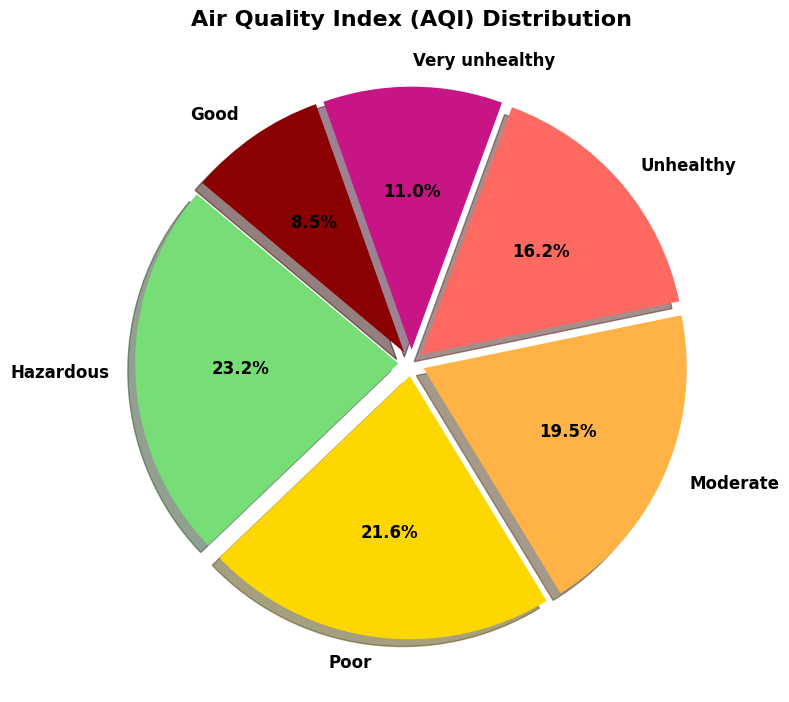

In [25]:
import matplotlib.pyplot as plt

# ---- Step 1: Count the values for each AQI category ----
aqi_counts = data['AQI_Range'].value_counts()

# ---- Step 2: Create a Pie Chart ----
plt.figure(figsize=(8, 8))
colors = ['#77DD77', '#FFD700', '#FFB347', '#FF6961', '#C71585', '#8B0000']  # Color codes for categories
explode = (0.05, 0.05, 0.05, 0.05, 0.05, 0.05)  # Slightly separate each slice

plt.pie(
    aqi_counts,
    labels=aqi_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'weight': 'bold'}
)

# ---- Step 3: Customize Chart ----
plt.title('Air Quality Index (AQI) Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()

# ---- Step 4: Display ----
plt.show()


In [26]:
data['AQI_Range'].value_counts().sort_index()


AQI_Range
Good               723
Hazardous         1988
Moderate          1670
Poor              1844
Unhealthy         1384
Very unhealthy     942
Name: count, dtype: int64

In [27]:
# Splitting the dataset into Dependent and Independent columns¶
X=data[['SOi','Noi','Rpi','SPMi']]
Y=data['AQI']
X.head()
# we only select columns like soi, noi, rpi, spmi

,SOi,Noi,Rpi,SPMi
0,10.750,20.250,0.0,273.000000
1,8.125,11.625,0.0,413.488372
2,32.250,13.000,0.0,413.255814
3,0.625,3.500,0.0,422.790698
4,3.125,16.000,0.0,417.674419


In [28]:
Y.head()
# the AQI column is the target column

0    273.000000
1    413.488372
2    413.255814
3    422.790698
4    417.674419
Name: AQI, dtype: float64

In [29]:
print(data.columns)

Index(['state', 'location', 'type', 'so2', 'no2', 'rspm', 'spm', 'pm2_5',
       'SOi', 'Noi', 'Rpi', 'SPMi', 'AQI', 'AQI_Range'],
      dtype='object')


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# --- Step 1: Prepare Dataset ---
# Example target: 1 if 'so2' above median, else 0
data['target'] = (data['so2'] > data['so2'].median()).astype(int)
X = data[['so2', 'SOi']]
y = data['target']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Logistic Regression Metrics
Accuracy: 98.60%
Precision: 100.00%
Recall: 97.13%
F1 Score: 98.55%



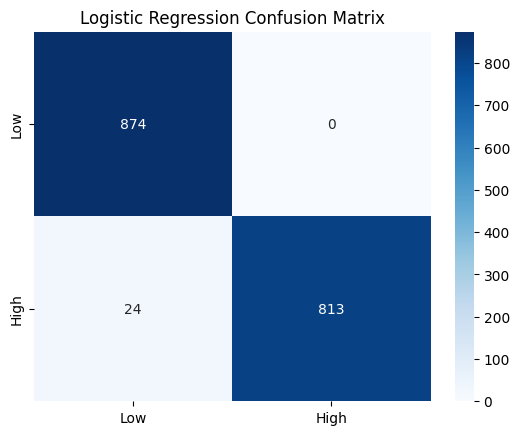

In [31]:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)

# Predict
y_pred_lr = lr.predict(X_test_scaled)

# Metrics
print("Logistic Regression Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_lr)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_lr)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_lr)*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("Logistic Regression Confusion Matrix")
plt.show()

Decision Tree Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%



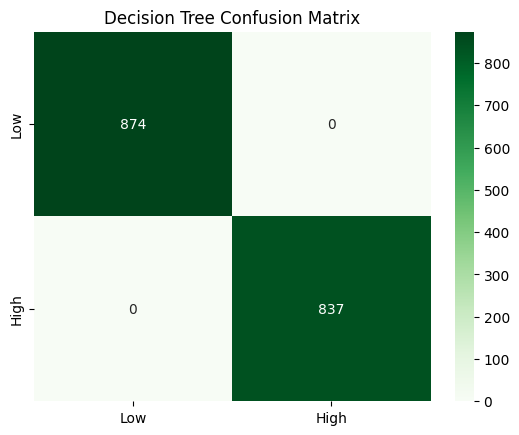

In [32]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

# Predict
y_pred_dt = dt.predict(X_test_scaled)

# Metrics
print("Decision Tree Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_dt)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_dt)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_dt)*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("Decision Tree Confusion Matrix")
plt.show()

KNN Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%



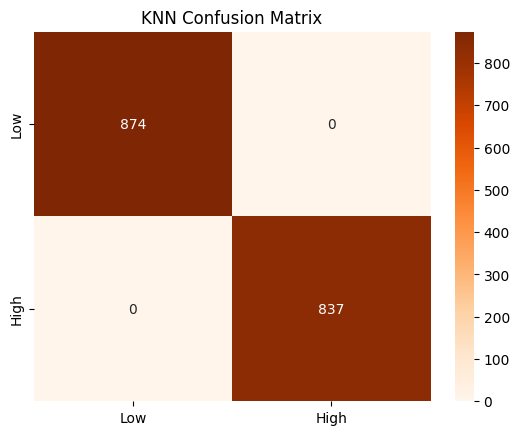

In [33]:
# from sklearn.neighbors import KNeighborsClassifier

# Train
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

# Predict
y_pred_knn = knn.predict(X_test_scaled)

# Metrics
print("KNN Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_knn)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_knn)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_knn)*100:.2f}%\n")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("KNN Confusion Matrix")
plt.show()


AdaBoost Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%



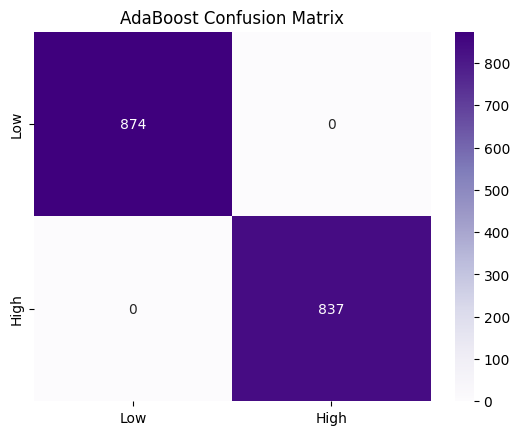

In [34]:
# from sklearn.ensemble import AdaBoostClassifier

# Train
ab = AdaBoostClassifier(random_state=42)
ab.fit(X_train_scaled, y_train)

# Predict
y_pred_ab = ab.predict(X_test_scaled)

# Metrics
print("AdaBoost Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ab)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_ab)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_ab)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_ab)*100:.2f}%\n")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_ab)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("AdaBoost Confusion Matrix")
plt.show()


XGBoost Metrics
Accuracy: 99.88%
Precision: 100.00%
Recall: 99.76%
F1 Score: 99.88%


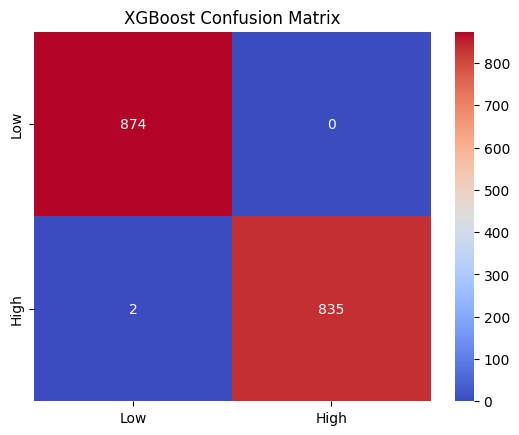

In [35]:
from xgboost import XGBClassifier

# Train
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
xgb.fit(X_train_scaled, y_train)

# Predict
y_pred_xgb = xgb.predict(X_test_scaled)

# Metrics
print("XGBoost Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb)*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("XGBoost Confusion Matrix")
plt.show()


Random Forest Metrics
Accuracy: 100.00%
Precision: 100.00%
Recall: 100.00%
F1 Score: 100.00%



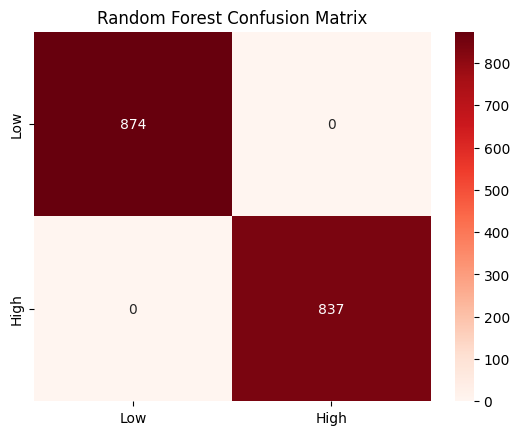

In [36]:
from sklearn.ensemble import RandomForestClassifier

# Train
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled, y_train)

# Predict
y_pred_rf = rf.predict(X_test_scaled)

# Metrics
print("Random Forest Metrics")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Precision: {precision_score(y_test, y_pred_rf)*100:.2f}%")
print(f"Recall: {recall_score(y_test, y_pred_rf)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, y_pred_rf)*100:.2f}%\n")


# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.title("Random Forest Confusion Matrix")
plt.show()


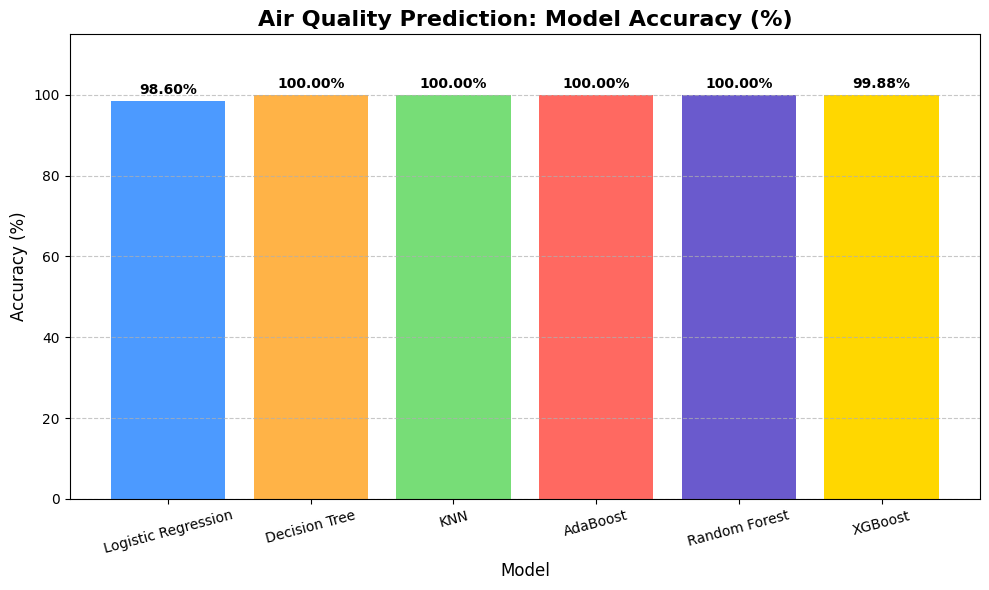

In [37]:
import matplotlib.pyplot as plt
import numpy as np

#  Step 1: Model names and Accuracy values 
models = ['Logistic Regression', 'Decision Tree', 'KNN', 'AdaBoost', 'Random Forest', 'XGBoost']
accuracy_values = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_dt),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_ab),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

# Convert to percentage
accuracy_percent = [v * 100 for v in accuracy_values]

#  Step 2: Plot Bar Chart 
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_percent, color=['#4C9AFF', '#FFB347', '#77DD77', '#FF6961', '#6A5ACD', '#FFD700'])

# Customize Plot
plt.title('Air Quality Prediction: Model Accuracy (%)', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.ylim(0, 115)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=15)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.2f}%', ha='center', va='bottom', fontweight='bold')

# Show plot
plt.tight_layout()
plt.show()


In [38]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#  Step 1: Model names 
models = ['Logistic Regression', 'Decision Tree', 'KNN', 'AdaBoost', 'Random Forest', 'XGBoost']

#  Step 2: Calculate metrics for each model 
metrics = {
    'Accuracy (%)': [
        round(accuracy_score(y_test, y_pred_lr)*100, 2),
        round(accuracy_score(y_test, y_pred_dt)*100, 2),
        round(accuracy_score(y_test, y_pred_knn)*100, 2),
        round(accuracy_score(y_test, y_pred_ab)*100, 2),
        round(accuracy_score(y_test, y_pred_rf)*100, 2),
        round(accuracy_score(y_test, y_pred_xgb)*100, 2)
    ],
    'Precision (%)': [
        round(precision_score(y_test, y_pred_lr)*100, 2),
        round(precision_score(y_test, y_pred_dt)*100, 2),
        round(precision_score(y_test, y_pred_knn)*100, 2),
        round(precision_score(y_test, y_pred_ab)*100, 2),
        round(precision_score(y_test, y_pred_rf)*100, 2),
        round(precision_score(y_test, y_pred_xgb)*100, 2)
    ],
    'Recall (%)': [
        round(recall_score(y_test, y_pred_lr)*100, 2),
        round(recall_score(y_test, y_pred_dt)*100, 2),
        round(recall_score(y_test, y_pred_knn)*100, 2),
        round(recall_score(y_test, y_pred_ab)*100, 2),
        round(recall_score(y_test, y_pred_rf)*100, 2),
        round(recall_score(y_test, y_pred_xgb)*100, 2)
    ],
    'F1-score (%)': [
        round(f1_score(y_test, y_pred_lr)*100, 2),
        round(f1_score(y_test, y_pred_dt)*100, 2),
        round(f1_score(y_test, y_pred_knn)*100, 2),
        round(f1_score(y_test, y_pred_ab)*100, 2),
        round(f1_score(y_test, y_pred_rf)*100, 2),
        round(f1_score(y_test, y_pred_xgb)*100, 2)
    ]
}

#  Step 3: Create DataFrame 
metrics_df = pd.DataFrame(metrics, index=models)

#  Step 4: Apply Styling 
styled_table = metrics_df.style \
    .background_gradient(cmap='YlGnBu') \
    .highlight_max(axis=0, color='lightgreen') \
    .set_properties(**{'font-weight': 'bold', 'text-align': 'center'}) \
    .format("{:.2f}%") \
    .set_caption("Air Quality Prediction: Model Performance Metrics (%)")

# Display the styled table
styled_table

#  Step 5: Format metrics with % for CSV 
metrics_df_formatted = metrics_df.copy()
metrics_df_formatted = metrics_df_formatted.applymap(lambda x: f"{x:.2f}%")

#  Step 6: Save formatted metrics to CSV 
metrics_df_formatted.to_csv("model_performance_metrics.csv", index=True)

print("CSV file 'model_performance_metrics.csv' has been created with formatted percentages.")




CSV file 'model_performance_metrics.csv' has been created with formatted percentages.


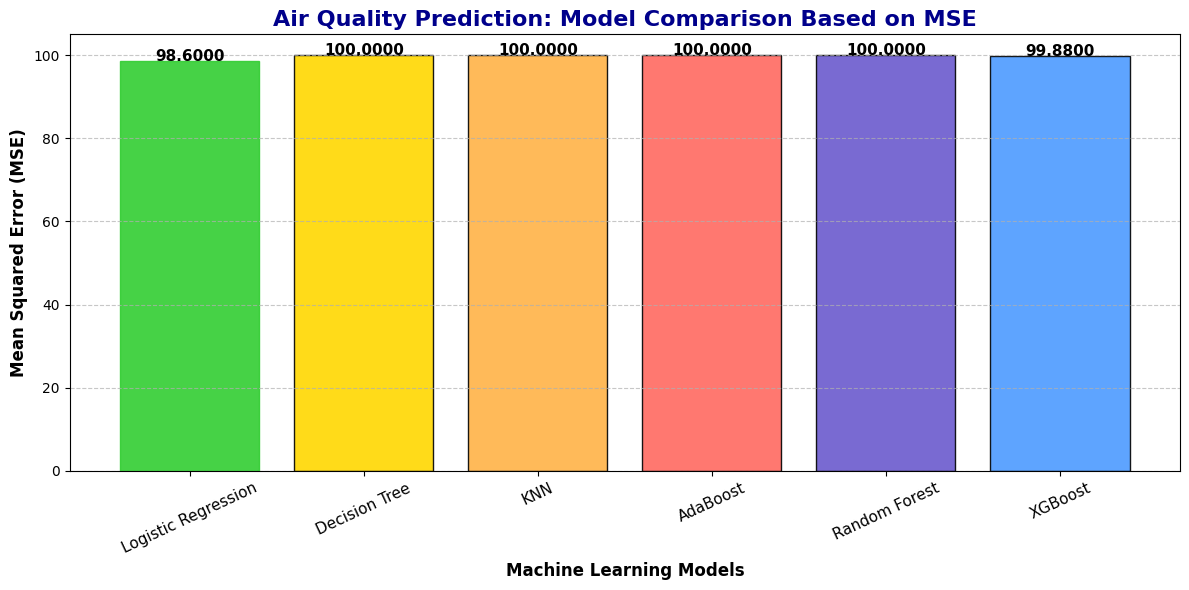

In [39]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Decision Tree', 'KNN', 'AdaBoost', 'Random Forest', 'XGBoost']
mse_values = [98.60, 100.00, 100.00, 100.00, 100.00, 99.88]


#  Step 3: Create Plot 
plt.figure(figsize=(12, 6))
colors = ['#77DD77', '#FFD700', '#FFB347', '#FF6961', '#6A5ACD', '#4C9AFF']
bars = plt.bar(models, mse_values, color=colors, edgecolor='black', alpha=0.9)

#  Step 4: Highlight Best Model (Lowest MSE) 
min_mse_index = mse_values.index(min(mse_values))
bars[min_mse_index].set_color('#32CD32')  # Bright green for best model

#  Step 5: Add Values on Top of Bars 
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0,
             height + 0.0005,               # Small gap above bar
             f'{height:.4f}',               # 4 decimal precision
             ha='center', fontsize=11, fontweight='bold', color='black')

#  Step 6: Customize Labels and Title 
plt.title("Air Quality Prediction: Model Comparison Based on MSE",
          fontsize=16, fontweight='bold', color='darkblue')
plt.xlabel("Machine Learning Models", fontsize=12, fontweight='bold')
plt.ylabel("Mean Squared Error (MSE)", fontsize=12, fontweight='bold')

# Rotate x-axis labels for clarity
plt.xticks(rotation=25, fontsize=11)

#  Step 7: Add Grid 
plt.grid(axis='y', linestyle='--', alpha=0.7)

#  Step 8: Tight Layout and Show 
plt.tight_layout()
plt.show()


Linear Regression